## Supplementary Figure 1

Enviorment: env 1

In [1]:
# env 1
import numpy as np
import os
import pandas as pd
import pickle
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, average_precision_score
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from tqdm import tqdm
import ast
import pickle
import os
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap


In [6]:
data_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia"

In [7]:
pd.set_option('display.max_rows', None)

In [8]:
def calculate_metrics(oof, oof_probs, cases, controls):
    prediction = []
    prob = []
    ground = []
    for key in oof.keys():
        if key in cases:
            prediction.append(oof[key])
            if oof_probs:
                prob.append(oof_probs[key])
            ground.append(1)
        elif key in controls:
            prediction.append(oof[key])
            if oof_probs:
                prob.append(oof_probs[key])
            ground.append(0)
        else:
            # exclude if missing
            print(key + " is missing ground truth")
    f1 = f1_score(ground, prediction)
    tn, fp, fn, tp = confusion_matrix(ground, prediction).ravel().tolist()
    tpr = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0
    tnr = tn / (tn + fp) if (tn + fp) else 0
    ppv = tp / (tp + fp) if (tp + fp) else 0
    npv = tn / (tn + fn) if (tn + fn) else 0
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0
    if oof_probs:
        auc = roc_auc_score(ground, prob)
        ap = average_precision_score(ground, prob)
    else:
        auc = None
        ap = None
    return {
        "f1": f1,
        "true positive rate": tpr,
        "true negative rate": tnr,
        "false positive rate": fpr,
        "positive predictive value": ppv,
        "negative predictive value": npv,
        "auc": auc,
        "acc": acc,
        "ap": ap
    }

### bl plots

In [9]:
# for the bl pkls (new)
# 0: hps: f1 dictionary
# 1: hps: oof probs dictionary
# 2: hps: oof preds dictionary

In [10]:
bl_file_names = os.listdir(f"{data_path}/rev_strat_pec_hc_pw1/run_20260407_stable/rev_strat_pec_hc_pw1_pickles_temp")
len(bl_file_names)

99

In [12]:
cases_path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl"
with open(cases_path, "rb") as f:
    cases = pickle.load(f)
    cases = [item.lower() for item in cases]
    print("cases: " + str(len(list(set(cases)))))

controls = {}
for i in range(1, 6):
    controls_path = f"/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_strat_hc_pw{i}_controls_20260403.pkl"
    with open(controls_path, "rb") as f:
        controls[i] = pickle.load(f)
        controls[i] = [item.lower() for item in controls[i]]
        print("controls: " + str(len(list(set(controls[i])))))

cases: 54
controls: 228
controls: 226
controls: 224
controls: 229
controls: 229


In [13]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

In [14]:
red_to_black = LinearSegmentedColormap.from_list(
    "red_to_black", 
    ["red", "black"]
)

In [ ]:
def plot_hyperparameter_performance(bl, data_path, cases, controls, thresh=0.6, title="", legend=False):
    """
    hp performance scatter plots
    """
    
    files = []
    oof_data = {}
    oof_probs = {}
    oof_metrics = []
    
    for pw in range(1, 6):
        pkl_path = f"{data_path}/rev_strat_pec_hc_pw{pw}/run_20260407/rev_strat_pec_hc_pw{pw}_pickles_temp"
        filepath = os.path.join(pkl_path, bl)
        files.append(filepath)
        oof_data[pw] = {}
        oof_probs[pw] = {}
    
    for i in range(5):
        with open(files[i], "rb") as f:
            data = pickle.load(f)
        hps = list(data[0].keys())
        for hp in hps:
            name = os.path.split(files[i])[-1][10:-4]
            with open(f"{pkl_path}/import/importance_{name}.pickle", "rb") as f:
                importance = pickle.load(f)
            hp_imp = importance[hp]
            hp_imp = np.array(list(hp_imp.values()))
            if "Logistic" in name:
                hp_imp = np.squeeze(hp_imp)
                hp_imp = np.abs(hp_imp)
            hp_imp = np.sum(hp_imp, axis=1)
            if (hp_imp == 0).any():
                print("skipping bl + hp combo due to importance", name, hp)
                continue
            oof_data[i + 1][hp] = data[2][hp]
            oof_probs[i + 1][hp] = data[1][hp]
            oof_metric = calculate_metrics(oof_data[i + 1][hp], oof_probs[i + 1][hp], cases, controls[i + 1])
            oof_metric["hp"] = hp
            oof_metric["pw"] = i + 1
            oof_metrics.append(oof_metric)
    
    oof_metrics_df = pd.DataFrame(oof_metrics)
    
    hp_summary = oof_metrics_df.groupby("hp").agg({
        'ap': ['mean', 'std', 'min', 'max'],
        'auc': ['mean', 'std', 'min', 'max']
    }).reset_index()
    
    hp_summary.columns = ['hp', 'ap_mean', 'ap_std', 'ap_min', 'ap_max', 
                          'auc_mean', 'auc_std', 'auc_min', 'auc_max']
    
    if hp_summary['auc_min'].max() < thresh:
        print("NOT MEETING THRESHOLD")
        return
    
    def parse_hp_string(hp_string):
        try:
            return ast.literal_eval(hp_string)
        except:
            return {}
    
    hp_dicts = hp_summary['hp'].apply(parse_hp_string).tolist()
    
    all_keys = set()
    for hp_dict in hp_dicts:
        all_keys.update(hp_dict.keys())
    
    for key in sorted(all_keys):
        hp_summary[key] = [hp_dict.get(key, None) for hp_dict in hp_dicts]
    
    ap_std_25th = hp_summary['ap_std'].quantile(0.25)
    
    hp_cols = [col for col in hp_summary.columns if col not in 
               ['hp', 'ap_mean', 'ap_std', 'ap_min', 'ap_max', 
                'auc_mean', 'auc_std', 'auc_min', 'auc_max']]
    
    for col in hp_cols:
        hp_summary[col] = hp_summary[col].fillna(-1)
    
    print(f"Available hyperparameters: {hp_cols}")
    print(f"\nDataFrame shape: {hp_summary.shape}")
    print(f"Number of unique hyperparameter combinations with non-zero FI: {len(hp_summary)}")
    
    if len(hp_cols) >= 1:
        fig, ax = plt.subplots(figsize=(4, 4), dpi=dpi)
        
        color_hp = hp_cols[0] if len(hp_cols) >= 1 else None
        size_hp = hp_cols[1] if len(hp_cols) >= 2 else None
        style_hp = hp_cols[2] if len(hp_cols) >= 3 else None
        
        scatter_kwargs = {
            'data': hp_summary,
            'x': 'ap_std',
            'y': 'auc_min',
            'alpha': 0.7,
            'ax': ax
        }
        
        if color_hp:
            scatter_kwargs['hue'] = color_hp
            scatter_kwargs['palette'] = red_to_black
        
        if size_hp:
            scatter_kwargs['size'] = size_hp
            scatter_kwargs['sizes'] = (50, 100)
        
        if style_hp:
            scatter_kwargs['style'] = style_hp
        
        sns.scatterplot(**scatter_kwargs)
        
        ax.axvline(x=ap_std_25th, color='black', linestyle='-', linewidth=2, 
                   label='25th percentile', alpha=0.7)
        
        ax.set_xlabel("STD AP", fontsize=12)
        ax.set_ylabel("MIN AUC", fontsize=12)
        ax.set_title("")
        ax.set_xlim(0, hp_summary['ap_std'].max() * 1.1)
        ax.set_ylim(hp_summary['auc_min'].min() * 0.9, hp_summary['auc_min'].max() * 1.1)
        
        plt.tight_layout()
        if legend:
            plt.legend(loc='lower left', fontsize=(font_size-2))
        else:
            plt.gca().get_legend().remove()
        plt.savefig(f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_1/{title}_0.pdf') 
        plt.show()
    
    if len(hp_cols) >= 4:
        fig, ax = plt.subplots(figsize=(4, 4), dpi=dpi)
        
        color_hp = hp_cols[3] if len(hp_cols) >= 4 else hp_cols[0]
        size_hp = hp_cols[4] if len(hp_cols) >= 5 else None
        style_hp = hp_cols[5] if len(hp_cols) >= 6 else None
        
        scatter_kwargs = {
            'data': hp_summary,
            'x': 'ap_std',
            'y': 'auc_min',
            'alpha': 0.7,
            'ax': ax
        }
        
        if color_hp:
            scatter_kwargs['hue'] = color_hp
            scatter_kwargs['palette'] = red_to_black
        
        if size_hp:
            scatter_kwargs['size'] = size_hp
            scatter_kwargs['sizes'] = (50, 100)
        
        if style_hp:
            scatter_kwargs['style'] = style_hp
        
        sns.scatterplot(**scatter_kwargs)
        
        ax.axvline(x=ap_std_25th, color='black', linestyle='-', linewidth=2, 
                   label='25th percentile', alpha=0.7)
        
        ax.set_xlabel("STD AP", fontsize=12)
        ax.set_ylabel("MIN AUC", fontsize=12)
        ax.set_title("")
        ax.set_xlim(0, hp_summary['ap_std'].max() * 1.1)
        ax.set_ylim(hp_summary['auc_min'].min() * 0.9, hp_summary['auc_min'].max() * 1.1)
        
        plt.tight_layout()
        if legend:
            plt.legend(loc='lower left', fontsize=(font_size-2))
        else:
            plt.gca().get_legend().remove()
        plt.savefig(f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_1/{title}_1.pdf') 
        plt.show()
    
    print("\n=== Summary Statistics ===")
    print(f"AP std range: [{hp_summary['ap_std'].min():.4f}, {hp_summary['ap_std'].max():.4f}]")
    print(f"AP std 25th percentile: {ap_std_25th:.4f}")
    print(f"AUC mean range: [{hp_summary['auc_min'].min():.4f}, {hp_summary['auc_min'].max():.4f}]")
    print(f"\nBest hyperparameter by lowest AP std:")
    best_idx = hp_summary['ap_std'].idxmin()
    print(hp_summary.loc[best_idx, ['hp', 'ap_mean', 'ap_std', 'auc_min', 'auc_std']])
    
    return hp_summary

In [18]:
bls_to_analyze = os.listdir(f"{data_path}/rev_strat_pec_hc_pw5/run_20260407_stable/rev_strat_pec_hc_pw5_pickles_temp")
len(bls_to_analyze)

99

Available hyperparameters: ['max_depth', 'max_features', 'min_samples_leaf', 'min_samples_split', 'n_estimators']

DataFrame shape: (72, 14)
Number of unique hyperparameter combinations with non-zero FI: 72


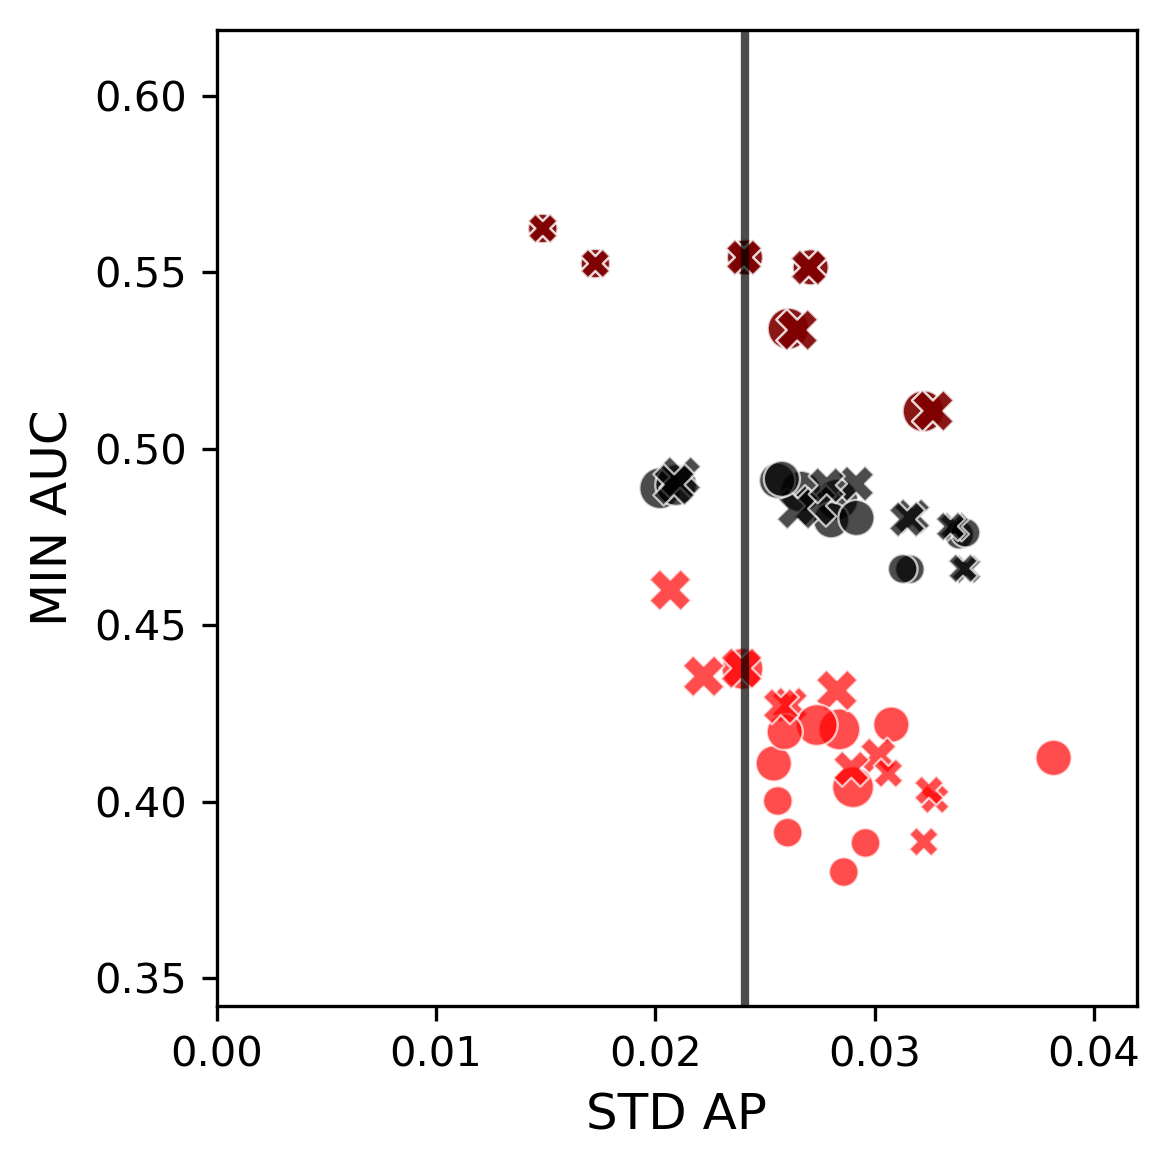

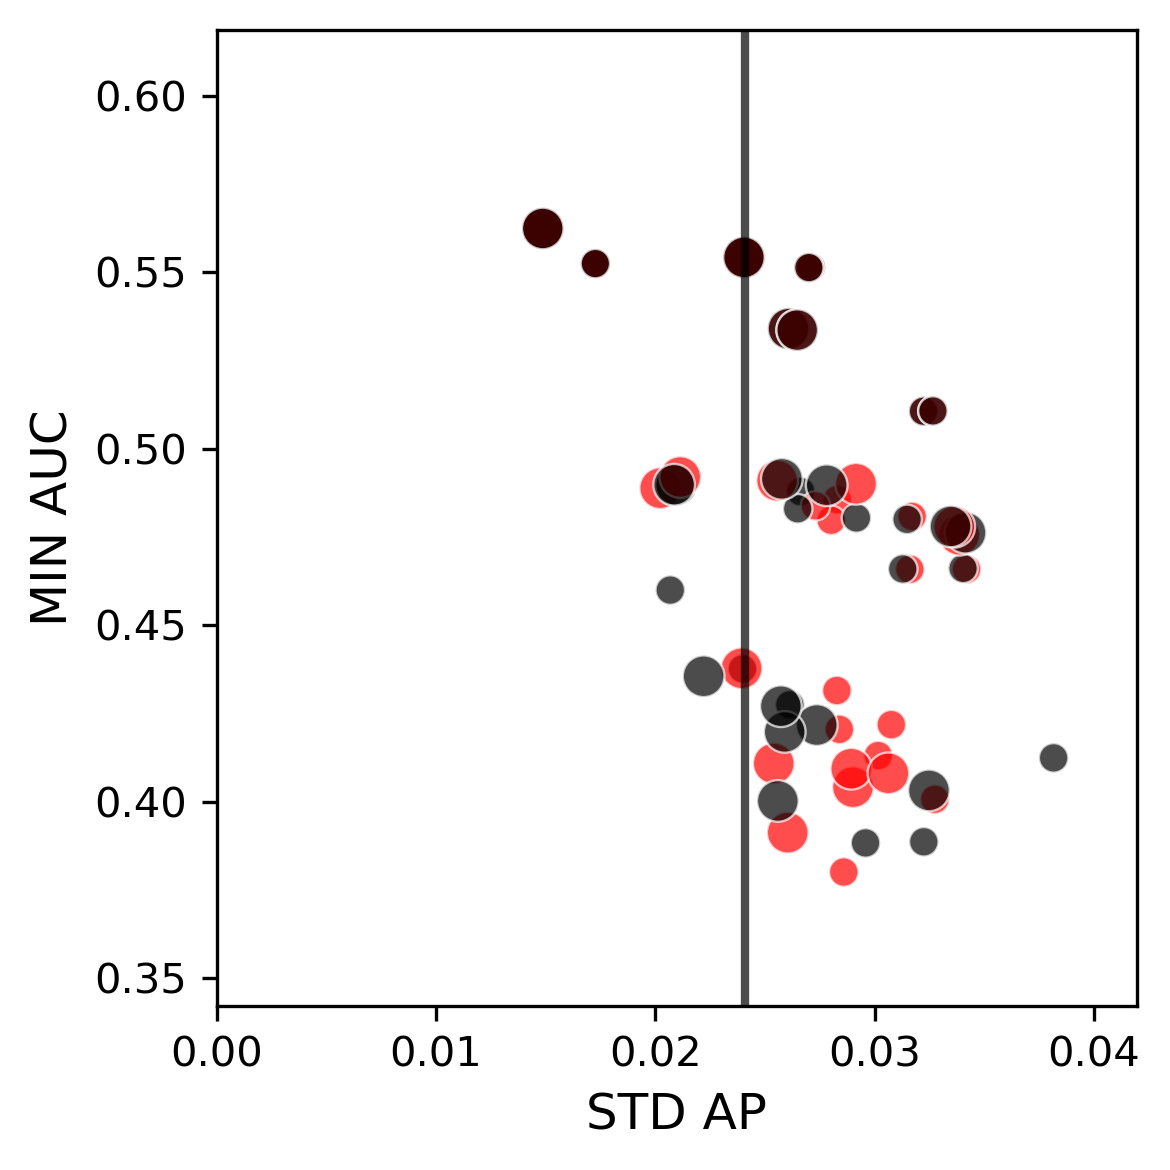


=== Summary Statistics ===
AP std range: [0.0149, 0.0382]
AP std 25th percentile: 0.0241
AUC mean range: [0.3801, 0.5624]

Best hyperparameter by lowest AP std:
hp         {'n_estimators': 200, 'max_depth': 1, 'min_sam...
ap_mean                                             0.241637
ap_std                                               0.01487
auc_min                                             0.562429
auc_std                                             0.019185
Name: 38, dtype: object


In [19]:
plot_hyperparameter_performance(
    [bl for bl in bls_to_analyze if ("box" in bl and "Random" in bl)][0],
    data_path, cases, controls, thresh=0.5, title="Box Counting RF", legend=False
);

Available hyperparameters: ['max_depth', 'max_features', 'min_samples_leaf', 'min_samples_split', 'n_estimators']

DataFrame shape: (72, 14)
Number of unique hyperparameter combinations with non-zero FI: 72


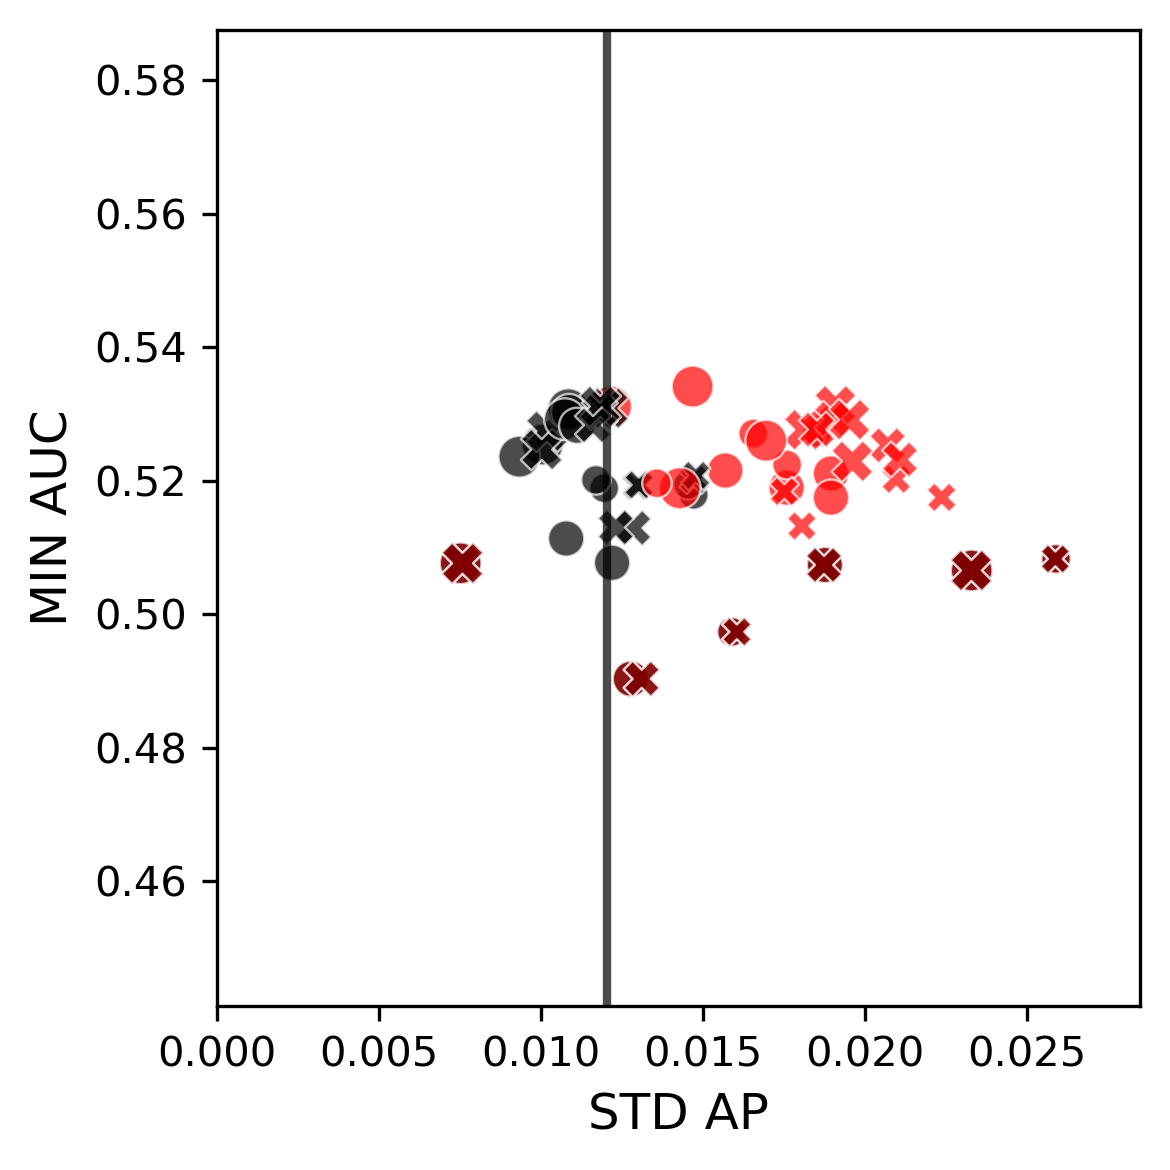

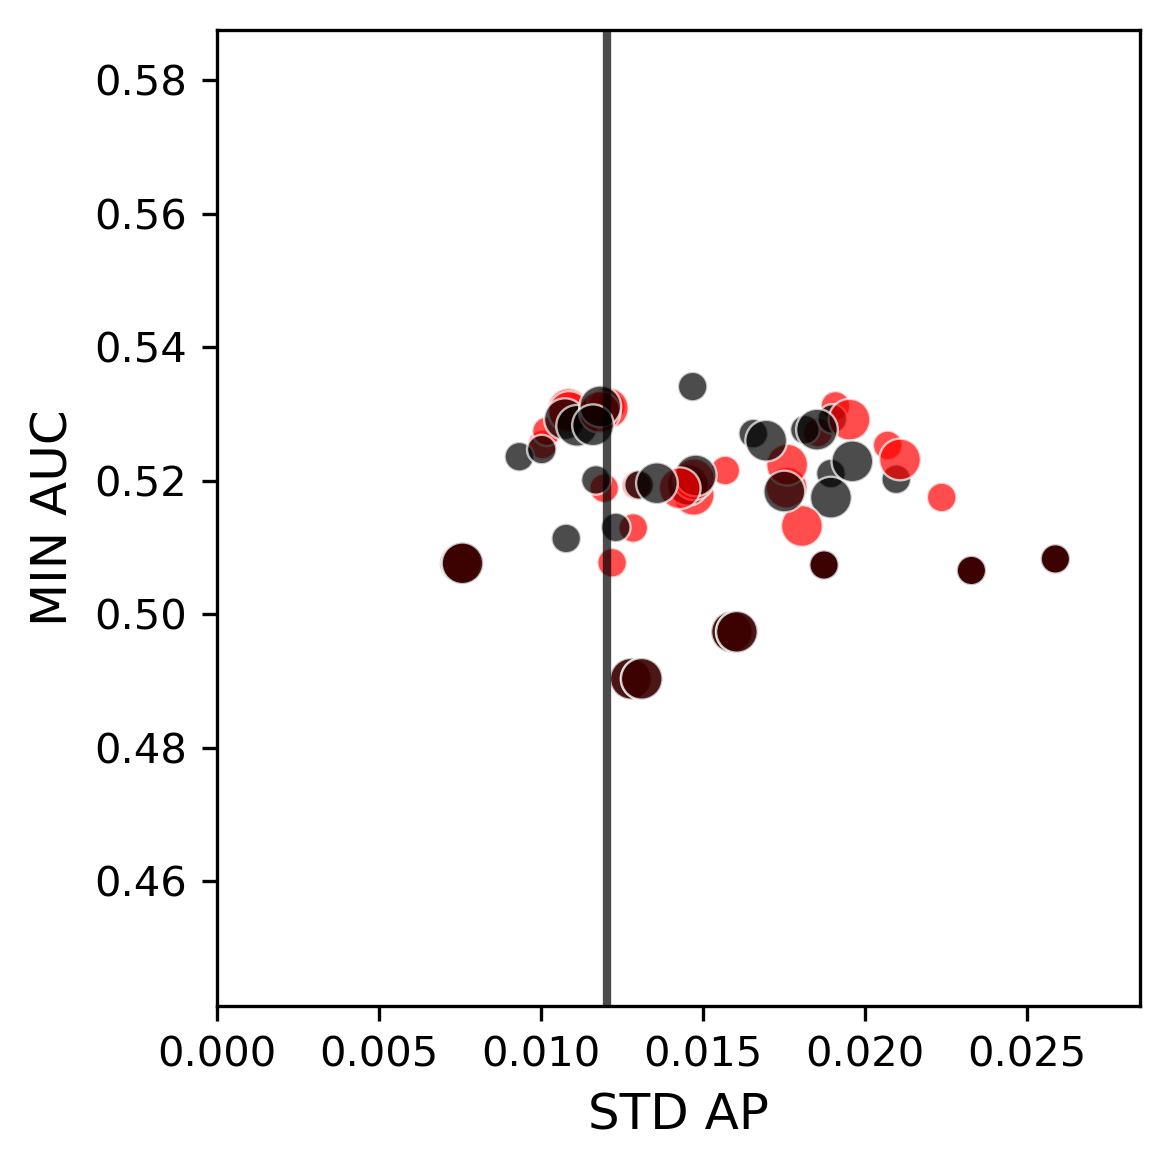


=== Summary Statistics ===
AP std range: [0.0075, 0.0259]
AP std 25th percentile: 0.0120
AUC mean range: [0.4903, 0.5341]

Best hyperparameter by lowest AP std:
hp         {'n_estimators': 200, 'max_depth': 1, 'min_sam...
ap_mean                                             0.195768
ap_std                                              0.007531
auc_min                                             0.507621
auc_std                                             0.011077
Name: 36, dtype: object


In [20]:
plot_hyperparameter_performance(
    [bl for bl in bls_to_analyze if ("cum" in bl and "Random" in bl)][0],
    data_path, cases, controls, thresh=0.5, title="Cum. Size Dist. RF"
);

Available hyperparameters: ['max_depth', 'max_features', 'min_samples_leaf', 'min_samples_split', 'n_estimators']

DataFrame shape: (72, 14)
Number of unique hyperparameter combinations with non-zero FI: 72


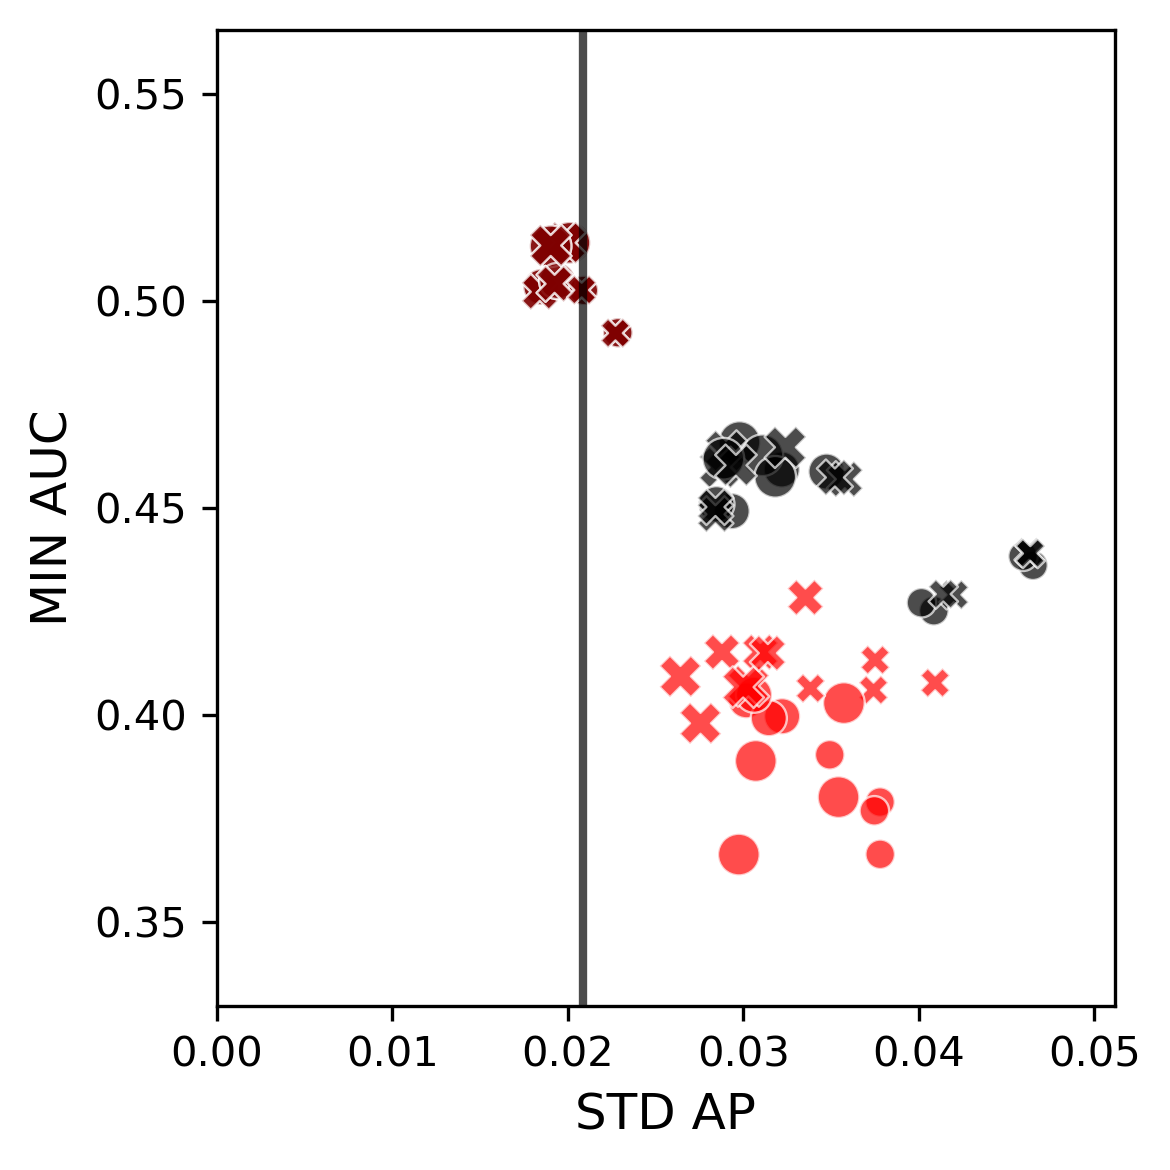

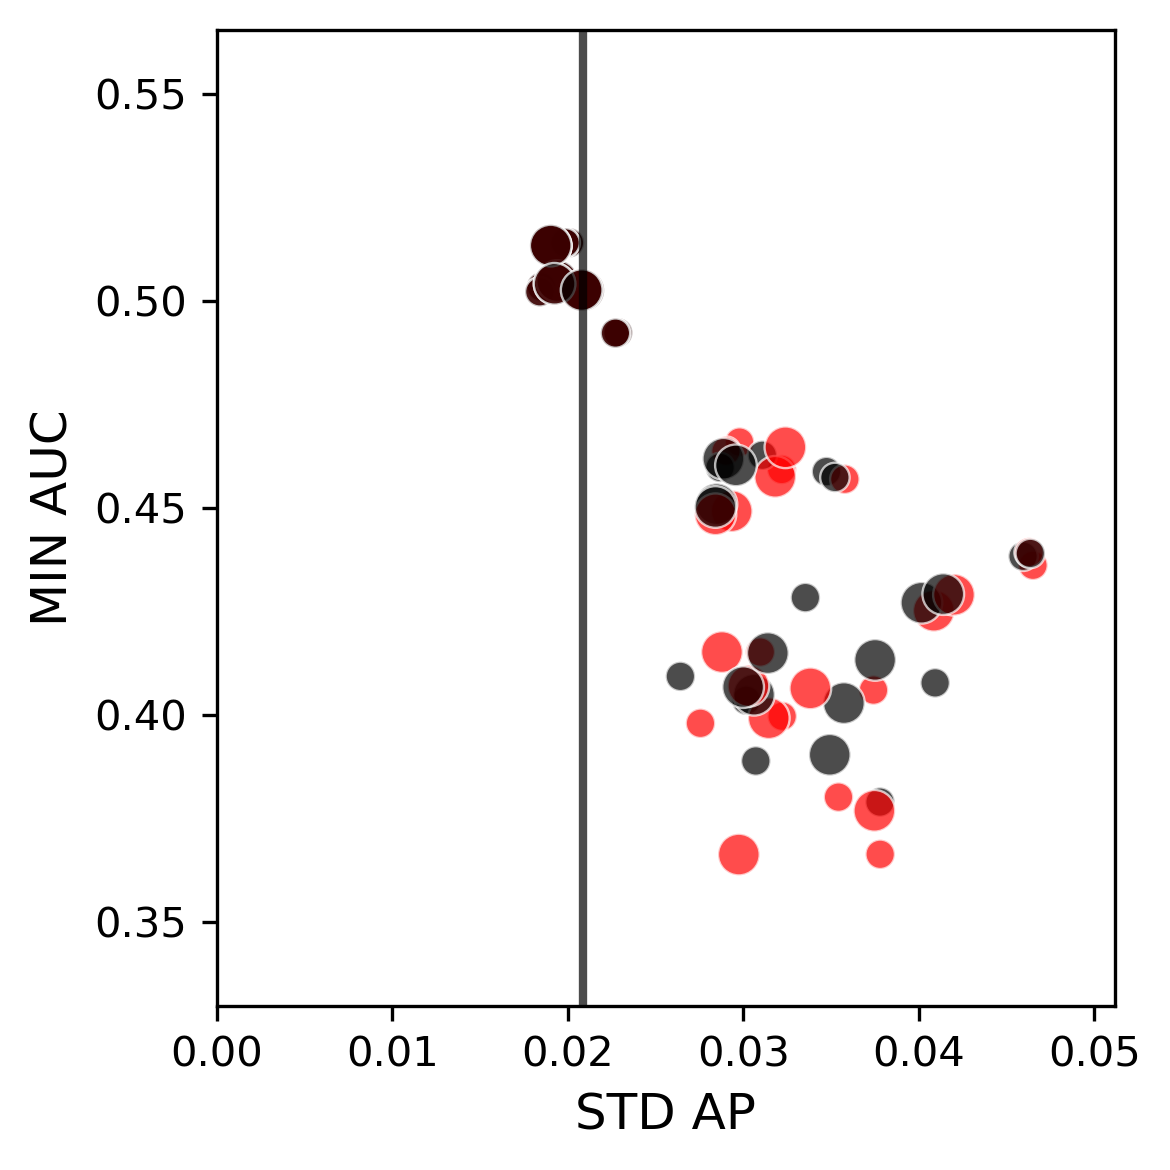


=== Summary Statistics ===
AP std range: [0.0184, 0.0465]
AP std 25th percentile: 0.0209
AUC mean range: [0.3663, 0.5142]

Best hyperparameter by lowest AP std:
hp         {'n_estimators': 100, 'max_depth': 1, 'min_sam...
ap_mean                                              0.22737
ap_std                                              0.018411
auc_min                                             0.502306
auc_std                                             0.025067
Name: 7, dtype: object


In [21]:
plot_hyperparameter_performance(
    [bl for bl in bls_to_analyze if ("cols" in bl and "Random" in bl)][0],
    data_path, cases, controls, thresh=0.5, title="Graph RF"
);